## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually

In [1]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
!pip install dotenv
!pip install FinRL
!pip install stable_baselines3
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install wrds
!pip install websockets
!pip install yfinance
!pip install ta
!pip install sb3_contrib
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d==1.4.0
!pip install mamba-ssm==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.2/127.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [2]:
import os
import sys

# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [4]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
import os
import sys
from google.colab import drive

drive.mount('/content/drive')

# NOTE: CHANGE PATH AS NECESSARY
PATH = '/content/drive/MyDrive/ELEN6885 Final Project'
sys.path.append(os.path.join(PATH, 'rl-trading'))
os.makedirs(os.path.join(PATH, 'data'), exist_ok=True)
os.makedirs(os.path.join(PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(PATH, 'tensorboard_logs'), exist_ok=True)

Mounted at /content/drive


In [5]:
from dotenv import load_dotenv
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from gymnasium import spaces
from finrl.meta.preprocessor.preprocessors import data_split
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from mamba_ssm import Mamba

from trading_environment.custom_env import StockTradingEnv
from trading_environment import rewards
from experiments.normalization import MaskedVecNormalize
from experiments.early_stopping import MultiCondEarlyStop
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest
from evaluation import financial_metrics
from evaluation.get_policy_distributions import get_policy_distributions
from evaluation.plot_stock_distribution import plot_stock_distribution
from evaluation.plot_policy_comparison import plot_policy_comparison
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/dis

In [6]:
if not torch.cuda.is_available():
  raise Exception('Please use a GPU compute')

## Load env variables

In [7]:
load_dotenv(r'../.env')

try:
  DATA_DIR = os.getenv('DATA_DIR', os.path.join(PATH, 'data'))
except:
  DATA_DIR = None
print(DATA_DIR)

/content/drive/MyDrive/ELEN6885 Final Project/data


In [8]:
# record experiment start dt
import datetime

EXP_START_DT = datetime.datetime.now().strftime('%Y%m%d_%H%M')
EXP_START_DT

'20251215_0211'

## Feature Extractors

### MLP Feature Extractor

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(
        self, input_dim: int, hidden_dim: int = 64, output_dim: int = 1
    ):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, input_dim]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.out(x)
        return x

In [ ]:
class MLPFeaturesExtractor(BaseFeaturesExtractor):
    """
    Wrap SimpleMLP as a feature extractor.
    """
    def __init__(
        self, observation_space: spaces.Box, features_dim: int = 64
    ):
        super().__init__(observation_space, features_dim)

        # shape: (window_size, feature_dim)
        # will only use the latest (current) state, ignore lagged states
        input_dim = observation_space.shape[1]

        self.mlp = SimpleMLP(
            input_dim=input_dim,
            hidden_dim=features_dim,
            output_dim=features_dim
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: [batch_size, 100, 71]
        # batch_size = n_envs in VecEnv
        x = observations[:, -1, :] # get current state
        return self.mlp(x)

### Mamba Feature Extractor

In [9]:
class MambaEncoder(nn.Module):
    def __init__(self, input_dim, d_model, n_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.mamba_blocks = nn.ModuleList([
            Mamba(d_model=d_model, d_state=64, d_conv=4, expand=4)
            for _ in range(n_layers)
        ])
        self.block_norms = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(n_layers)
        ])
        self.out_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = x.float()
        if x.dim() == 2:
            x = x.unsqueeze(0)

        x = self.dropout(self.input_proj(x))

        for ln, block in zip(self.block_norms, self.mamba_blocks):
            h = ln(x)
            h = block(h)
            x = x + self.dropout(h)   # residual

            if not torch.isfinite(x).all():
                raise RuntimeError("Non-finite values after a Mamba block")

        x = self.out_norm(x)
        return x[:, -1, :]

In [10]:
class MambaFeatureExtractor(BaseFeaturesExtractor):
    def __init__(
        self,
        observation_space: spaces.Box,
        d_model: int = 128,
        n_layers: int = 2,
        dropout: float = 0.1,
    ):
        # obs shape: (window_size, features_dim)
        window_size, features_dim = observation_space.shape

        super().__init__(observation_space, features_dim=d_model)

        self.mamba_encoder = MambaEncoder(
            input_dim=features_dim,
            d_model=d_model,
            n_layers=n_layers,
            dropout=dropout,
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        if observations.dim() == 2:
            observations = observations.unsqueeze(0)

        out = self.mamba_encoder(observations)
        if not torch.isfinite(out).all():
            raise RuntimeError("Non-finite output from mamba_encoder")

        return out


## Train-test split and normalization

In [11]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

base_columns = [
    'date',	'tic', 'close',	'high',	'low', 'open', 'volume'
]

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    # 'doy_sin',
    # 'doy_cos',
    'dow_sin',
    'dow_cos'
]

In [12]:
# load finalized data
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))

data_df = data_df[base_columns + stock_features + economy_features]
stock_names = data_df['tic'].unique()
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

(67300, 19)

In [13]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()
print(min_date, max_date)

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE, end=max_date + pd.Timedelta(days=1))

print(train_df.shape, trade_df.shape)
print(train_df['date'].min(), train_df['date'].max())
print(trade_df['date'].min(), trade_df['date'].max())
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

1999-03-11 00:00:00 2025-12-09 00:00:00
(47340, 19) (19960, 19)
1999-03-11 00:00:00 2017-12-29 00:00:00
2018-01-02 00:00:00 2025-12-09 00:00:00
Any missing values in training: False
Any missing values in testing: False


## Environment configuration

In [14]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 1000             # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 50        # number of previous time steps to encode
# reward_func = rewards.PnLReward()
reward_func = rewards.PenalizedTurnover(penalty=5e-3)
reward_scaling = 1      # reward scaling

In [15]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_function": reward_func,
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Data normalization

In [16]:
## ----- CONFIG ----- ##
PARALLEL_RUNS = 10

In [17]:
# do not normalize prices, since they are used to compute rewards
# feature index starts after cash + prices * stock_dim + shares * stock_dim
feature_start_idx = 1 + 2 * stock_dim

In [18]:
def make_train_env():
    env = StockTradingEnv(df=train_df, **env_kwargs)
    env = Monitor(env, filename=f"training_monitor_mamba_{EXP_START_DT}", allow_early_resets=True)
    return env

def make_valid_env():
    env = StockTradingEnv(df=trade_df, **env_kwargs)
    env = Monitor(env, filename=f"trading_monitor_mamba_{EXP_START_DT}", allow_early_resets=True)
    return env

In [19]:
train_vec_env = DummyVecEnv([make_train_env for _ in range(PARALLEL_RUNS)])

obs_shape = train_vec_env.observation_space.shape   # (window_size, feature_dim)

# features_to_normalize = list of indices along the *feature_dim* axis
normalize_mask = np.zeros(obs_shape, dtype=bool)
# broadcast those feature indices over all time steps
normalize_mask[:, feature_start_idx:] = True

# Wrap training env with MaskedVecNormalize (this FITS the stats)
train_norm_env = MaskedVecNormalize(
    train_vec_env,
    normalize_mask=normalize_mask.any(axis=0),
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=True
)

###Load Model

In [44]:
from stable_baselines3 import PPO

model_mamba = PPO.load(
    '/content/drive/MyDrive/ELEN6885 Final Project/models/mamba_ppo_model_20251214_2038.zip'
    )

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## Policy Analysis

In [26]:
mean_base, std_base, mean_high, std_high, avg_vix, high_vix = get_policy_distributions(
    model=model_mamba,
    valid_norm_env=valid_norm_env,
    train_df=train_df,
    vix_idx=66
)

sorted_tickers = sorted(train_df['tic'].unique())

diff = np.abs(mean_base - mean_high).max()

print(f"Raw Baseline VIX: {avg_vix:.2f}")
print(f"Raw High VIX:     {high_vix:.2f}")
print(f"\nMax Action Difference: {diff:.6f}")

print("\n--- Baseline Means ---")
print(mean_base)
print("\n--- High VIX Means ---")
print(mean_high)

Raw Baseline VIX: 20.03
Raw High VIX:     32.92

Max Action Difference: 0.000000

--- Baseline Means ---
[571.43036    -17.638575   -11.128213    -5.649239    -2.2766173
 -11.341203   -12.22826    -14.800363     0.86336845 -15.62105   ]

--- High VIX Means ---
[571.43036    -17.638575   -11.128213    -5.649239    -2.2766173
 -11.341203   -12.22826    -14.800363     0.86336845 -15.62105   ]


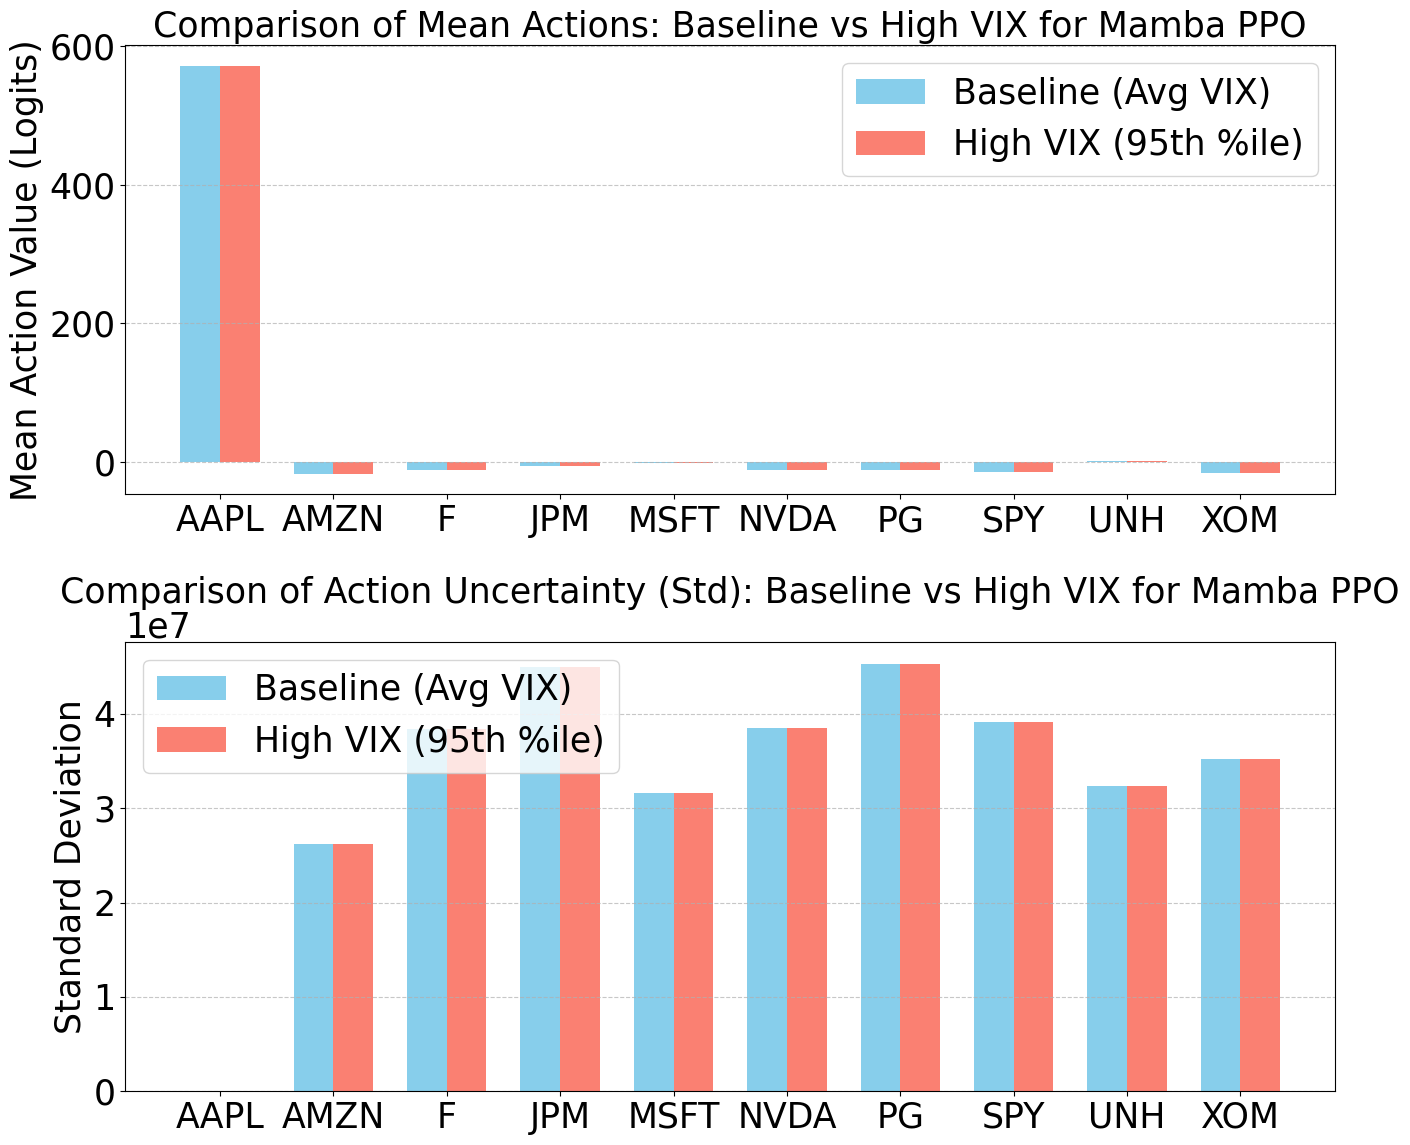

In [47]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Set global font sizes for labels and titles
plt.rcParams.update({
    'font.size': 25,          # default font size
    'axes.titlesize': 25,     # font size for titles
    'axes.labelsize': 25,     # font size for x and y labels
    'xtick.labelsize': 25,    # font size for x-axis tick labels
    'ytick.labelsize': 25,    # font size for y-axis tick labels
    'legend.fontsize': 25,    # font size for legend
})

# Ensure stock names are available
if 'sorted_tickers' not in locals():
    sorted_tickers = sorted(train_df['tic'].unique())

# Call the function with the variables expected to be in the global scope
plot_policy_comparison(sorted_tickers, mean_base, mean_high, std_base, std_high, "Mamba PPO")


--- Stock: AAPL ---
Baseline: Mean=571.4303588867188, Std=353.71337890625
High VIX: Mean=571.4303588867188, Std=353.71337890625
Shift: 0.0


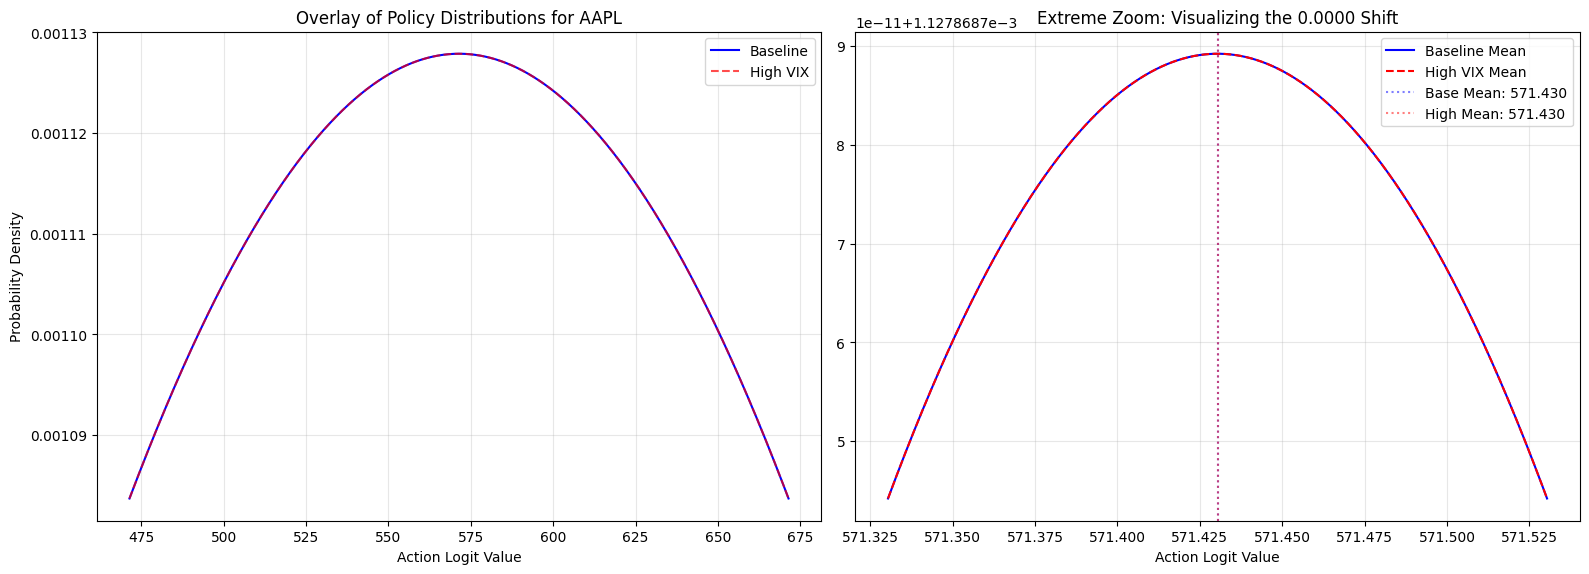


--- Stock: AMZN ---
Baseline: Mean=-17.638574600219727, Std=26150680.0
High VIX: Mean=-17.638574600219727, Std=26150680.0
Shift: 0.0


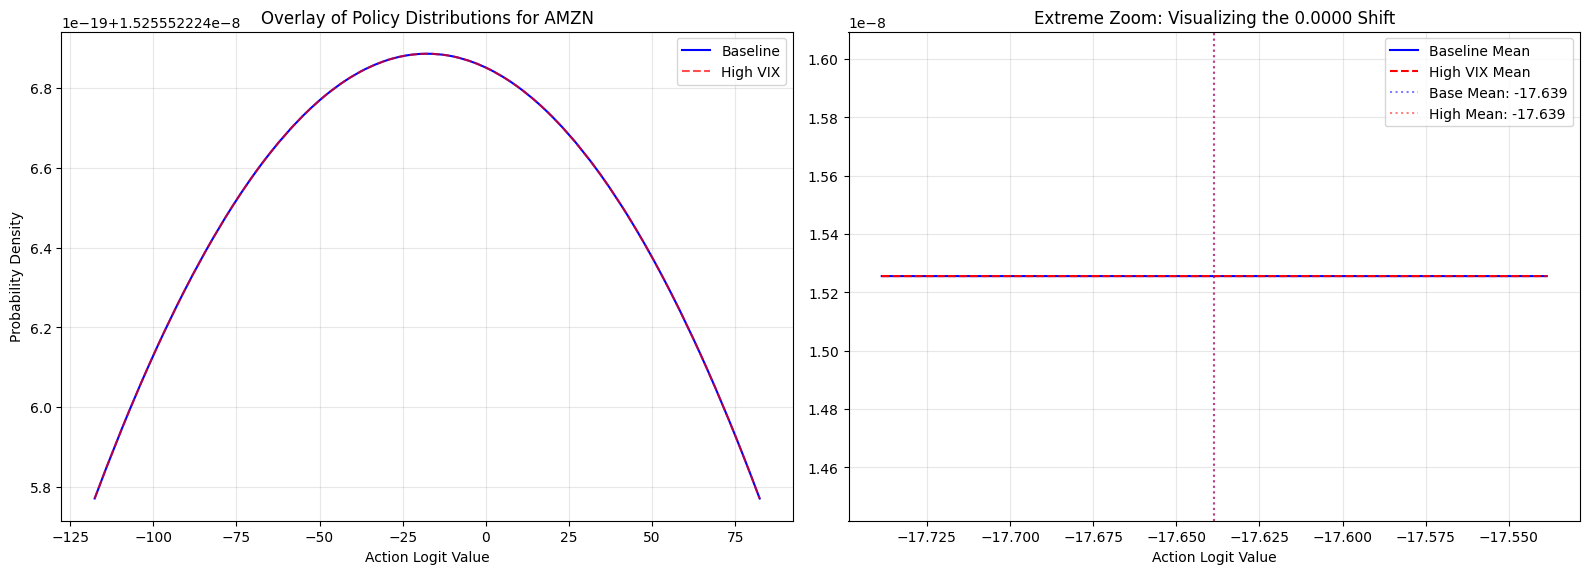


--- Stock: F ---
Baseline: Mean=-11.128212928771973, Std=38365508.0
High VIX: Mean=-11.128212928771973, Std=38365508.0
Shift: 0.0


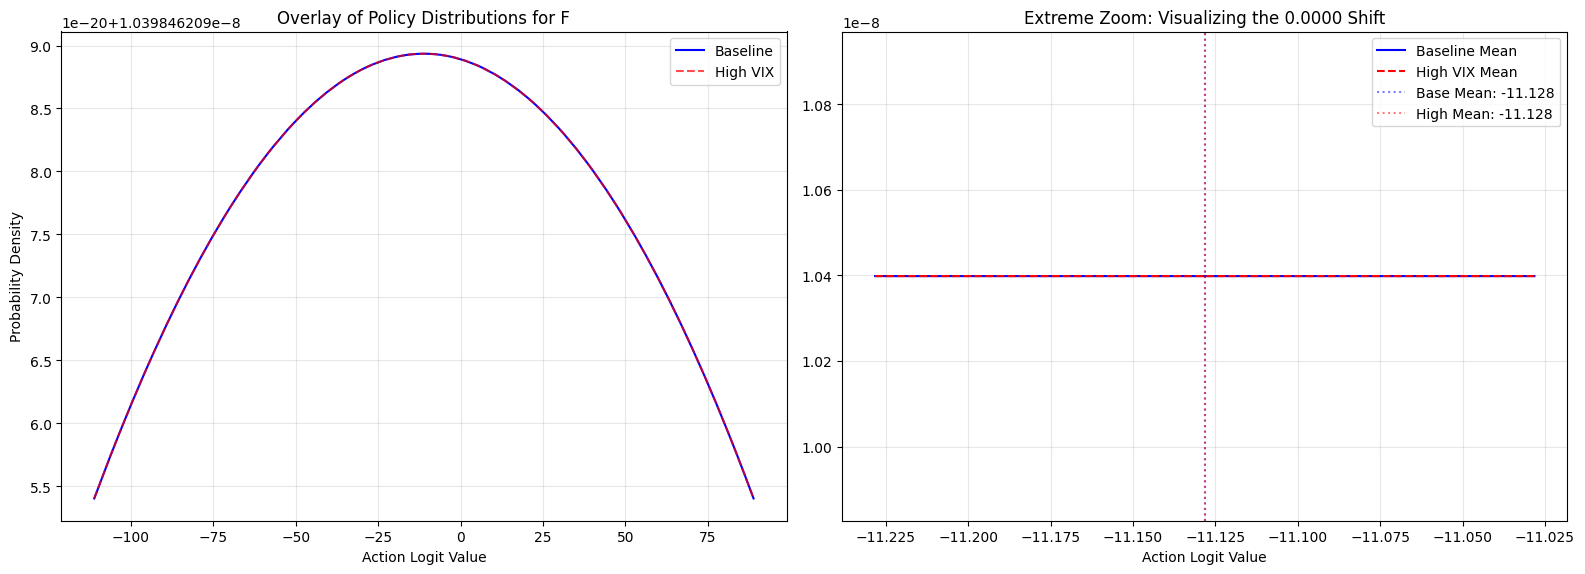


--- Stock: JPM ---
Baseline: Mean=-5.6492390632629395, Std=44952400.0
High VIX: Mean=-5.6492390632629395, Std=44952400.0
Shift: 0.0


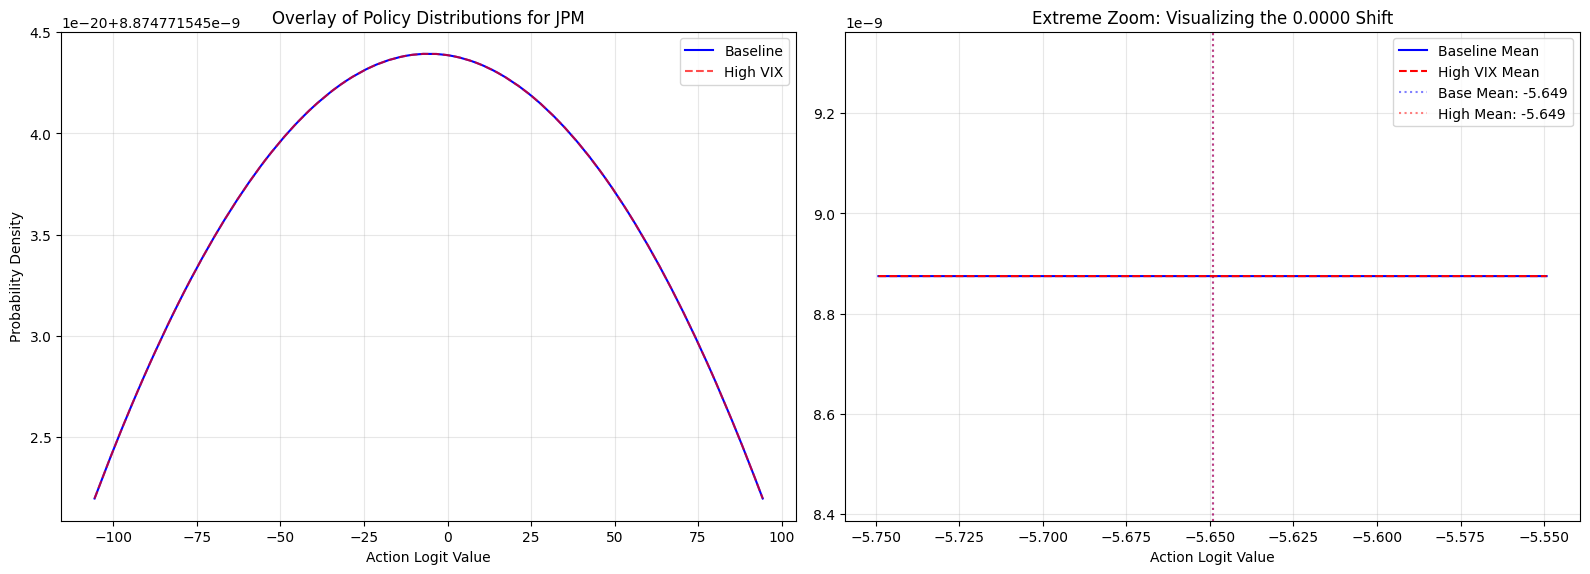


--- Stock: MSFT ---
Baseline: Mean=-2.2766172885894775, Std=31583356.0
High VIX: Mean=-2.2766172885894775, Std=31583356.0
Shift: 0.0


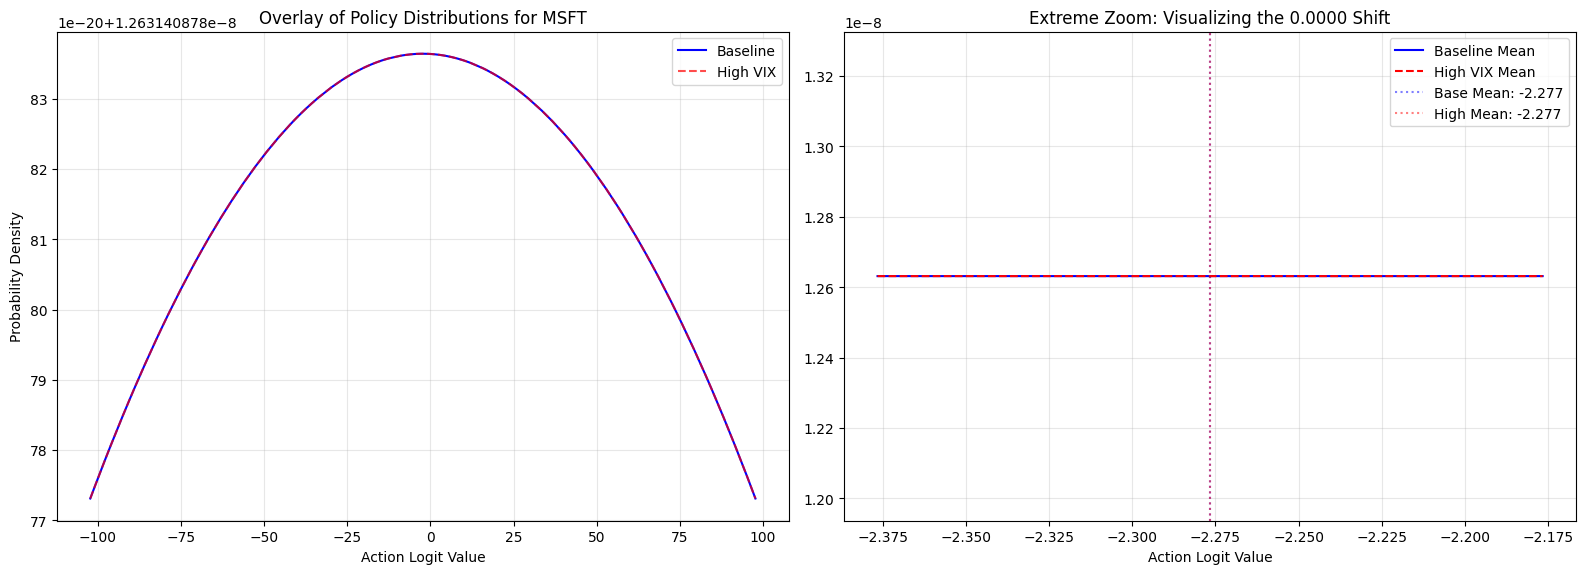


--- Stock: NVDA ---
Baseline: Mean=-11.341202735900879, Std=38545212.0
High VIX: Mean=-11.341202735900879, Std=38545212.0
Shift: 0.0


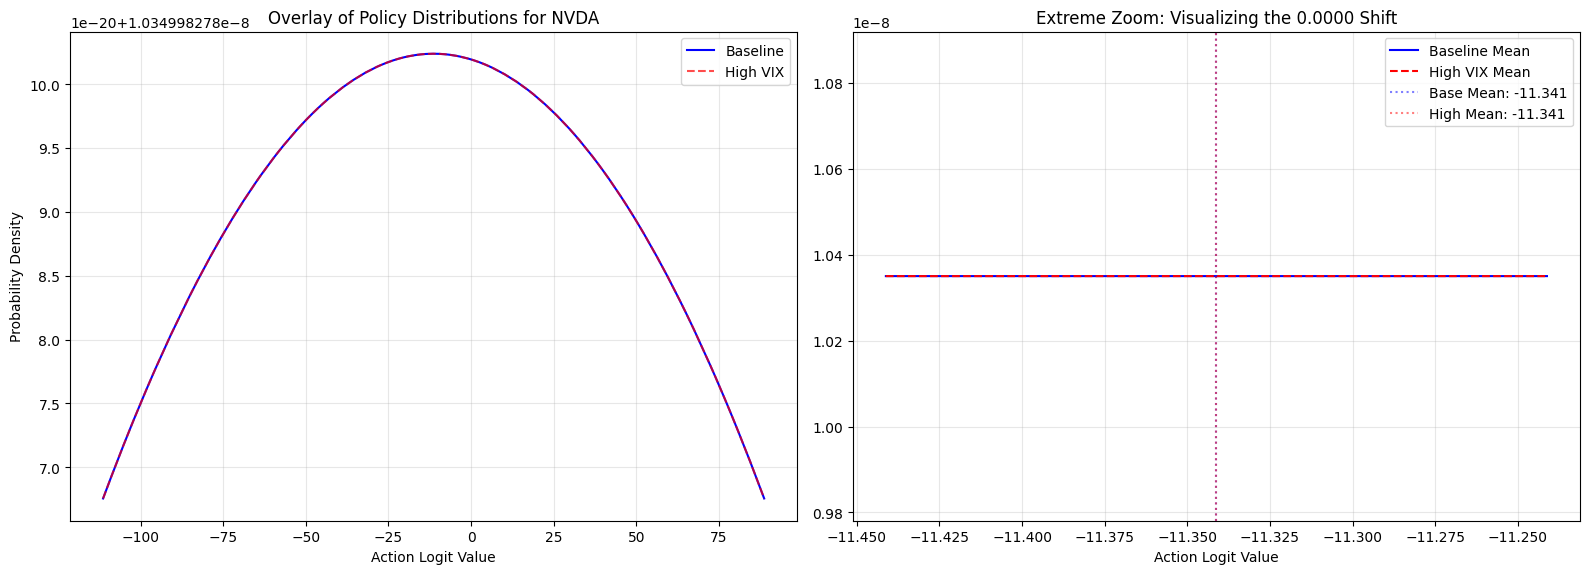


--- Stock: PG ---
Baseline: Mean=-12.228260040283203, Std=45322948.0
High VIX: Mean=-12.228260040283203, Std=45322948.0
Shift: 0.0


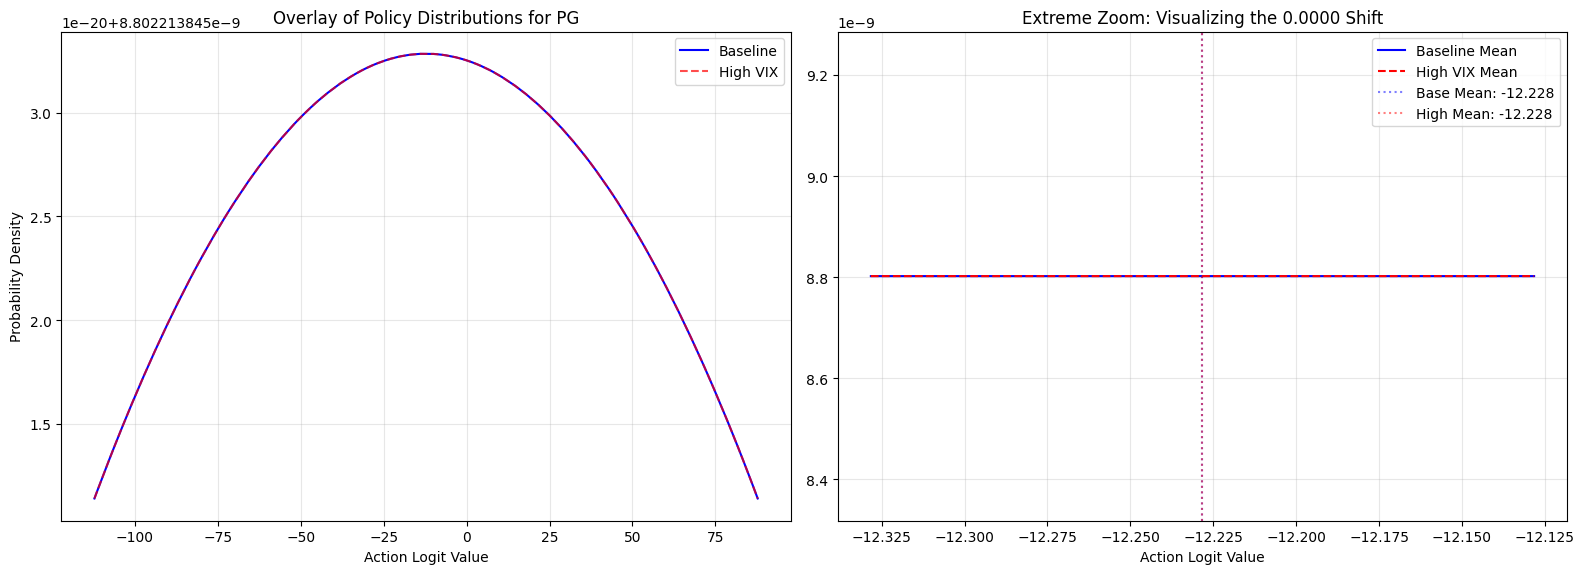


--- Stock: SPY ---
Baseline: Mean=-14.800362586975098, Std=39137052.0
High VIX: Mean=-14.800362586975098, Std=39137052.0
Shift: 0.0


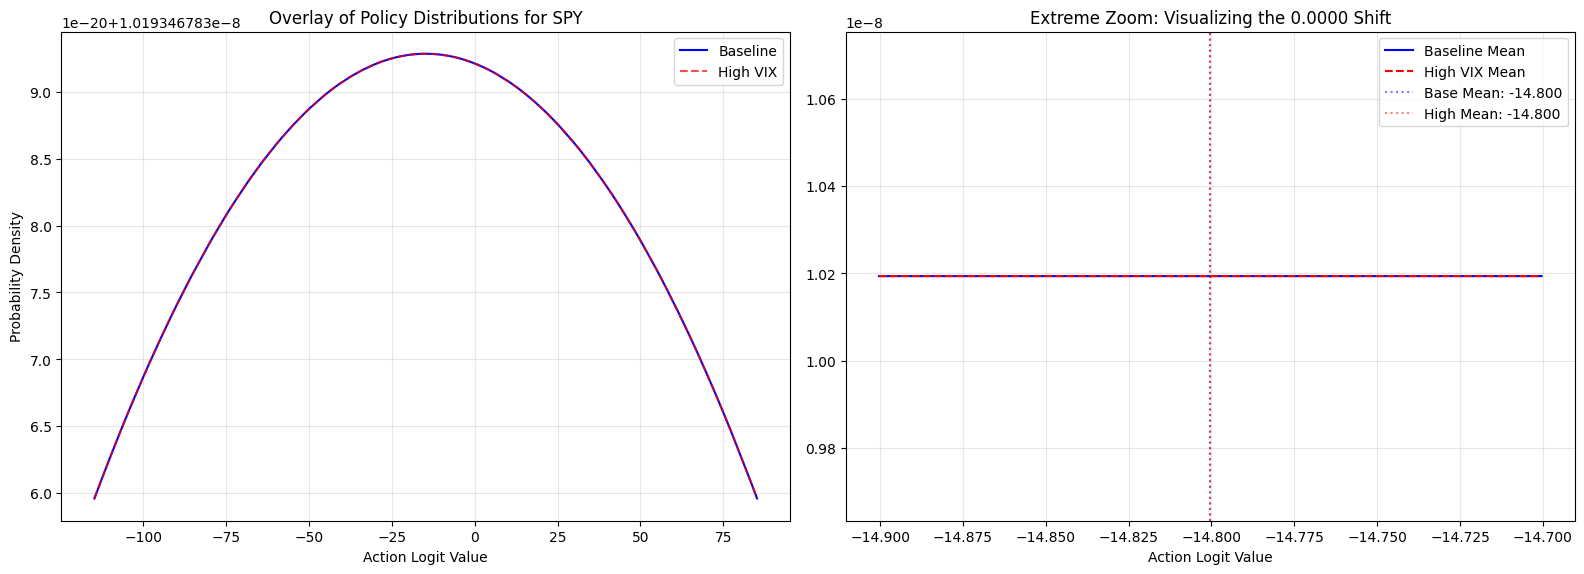


--- Stock: UNH ---
Baseline: Mean=0.8633684515953064, Std=32340166.0
High VIX: Mean=0.8633684515953064, Std=32340166.0
Shift: 0.0


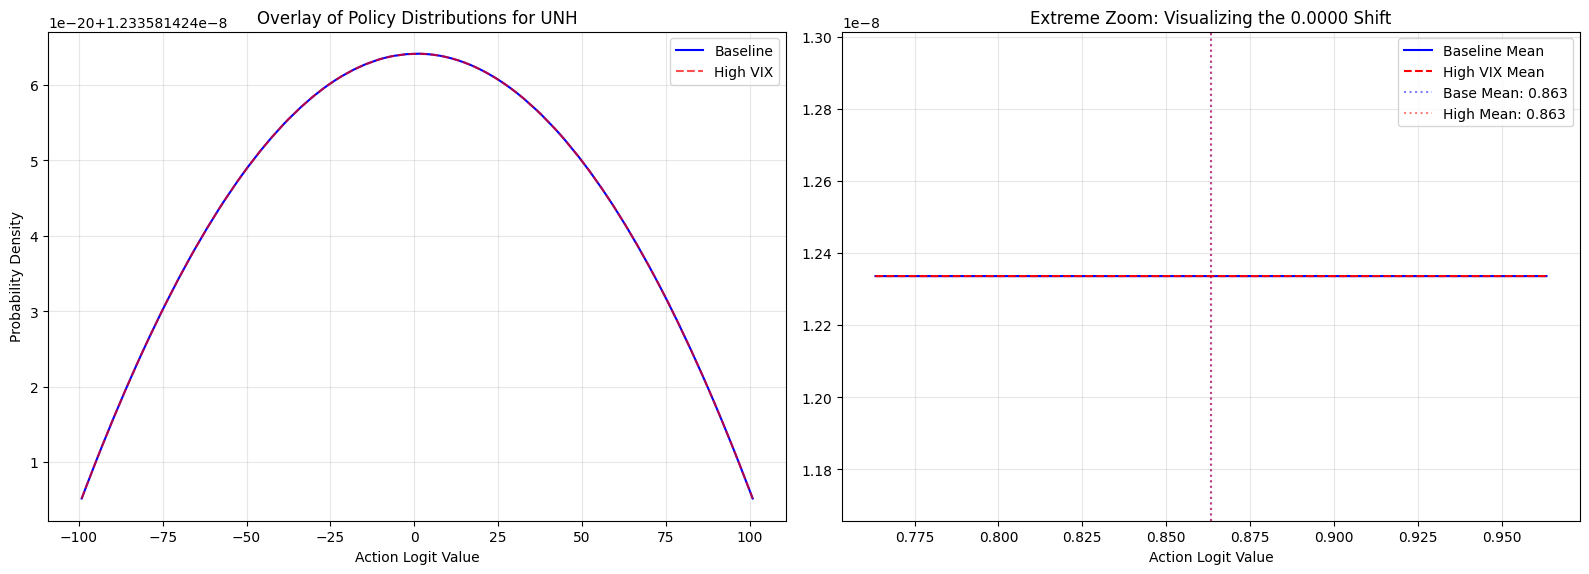


--- Stock: XOM ---
Baseline: Mean=-15.621049880981445, Std=35248028.0
High VIX: Mean=-15.621049880981445, Std=35248028.0
Shift: 0.0


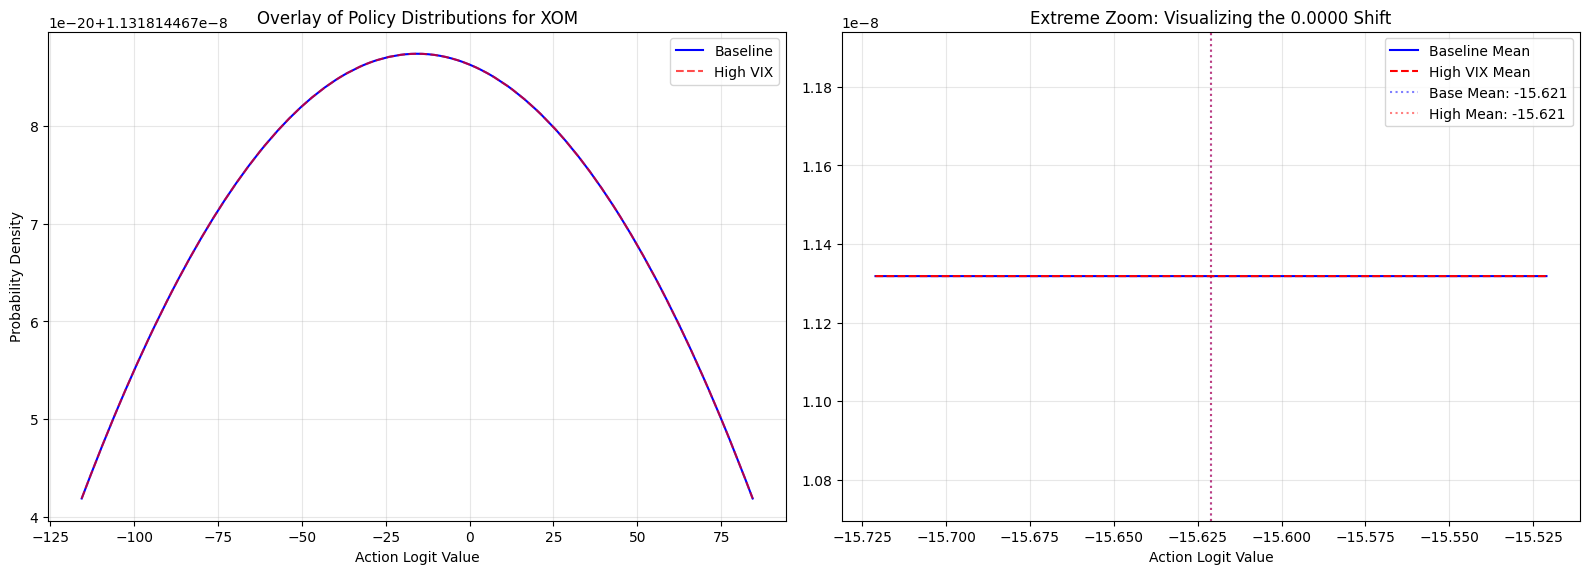

In [33]:
# Loop through all stocks and plot
for i in range(len(sorted_tickers)):
    plot_stock_distribution(i, sorted_tickers, mean_base, std_base, mean_high, std_high)

Average Weight Magnitude across all features: 0.1533
Max Weight Magnitude: 0.3290
VIX Feature (Index 66) Weight Magnitude:    0.1467

CONCLUSION: The model 'sees' the VIX feature, but the saturation in later layers is likely suppressing the reaction.


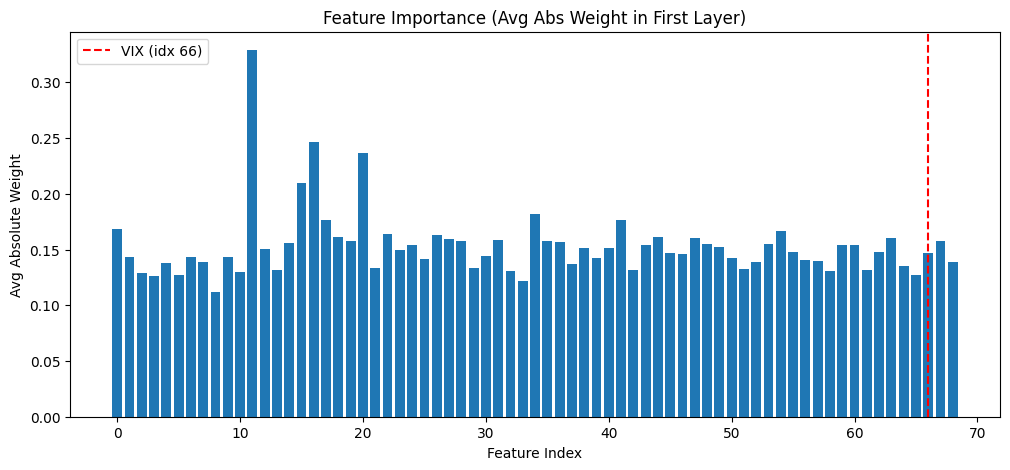

In [35]:
# Access the first linear layer
W = model_mamba.policy.features_extractor.mamba_encoder.input_proj.weight.detach().cpu().numpy()

feature_importance = np.abs(W).mean(axis=0)

# Get VIX importance
vix_importance = feature_importance[66]
avg_importance = feature_importance.mean()
max_importance = feature_importance.max()

print(f"Average Weight Magnitude across all features: {avg_importance:.4f}")
print(f"Max Weight Magnitude: {max_importance:.4f}")
print(f"VIX Feature (Index 66) Weight Magnitude:    {vix_importance:.4f}")

if vix_importance < avg_importance * 0.1:
    print("\nCONCLUSION: The model has effectively 'muted' the VIX feature (weights are very low).")
else:
    print("\nCONCLUSION: The model 'sees' the VIX feature, but the saturation in later layers is likely suppressing the reaction.")

# Plot feature importances
plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_importance)), feature_importance)
plt.axvline(66, color='r', linestyle='--', label='VIX (idx 66)')
plt.title("Feature Importance (Avg Abs Weight in First Layer)")
plt.xlabel("Feature Index")
plt.ylabel("Avg Absolute Weight")
plt.legend()
plt.show()

In [37]:
import copy
import numpy as np

# Define the missing variables
obs_baseline = valid_norm_env.reset()
vix_idx = 66

obs2 = copy.deepcopy(obs_baseline)
# Perturb the VIX feature (index 66) across all time steps
obs2[:, :, vix_idx] += 10.0

a1, _ = model_mamba.predict(obs_baseline, deterministic=True)
a2, _ = model_mamba.predict(obs2, deterministic=True)

print("max |action diff|:", np.max(np.abs(a2 - a1)))

max |action diff|: 0.00016635656356811523


In [40]:
import torch

obs_b = torch.as_tensor(obs_baseline).float().to(model_mamba.device)
obs_h = torch.as_tensor(obs2).float().to(model_mamba.device)

with torch.no_grad():
    fb = model_mamba.policy.extract_features(obs_b)
    fh = model_mamba.policy.extract_features(obs_h)

print("feature max abs diff:", (fh - fb).abs().max().item())

feature max abs diff: 0.005937337875366211
